In [1]:
# credit card fraud detection using azure ml
# using kaggle dataset with 284k transactions

print("Credit Card Fraud Detection Project")
print()
print("Team Members:")
print("  Jyotheswar Narayana Narravula")
print("  Mohith Reddy Kovvuri")
print("  Vaishnavi Madduri")
print()
print("Wright State University")

Credit Card Fraud Detection Project

Team Members:
  Jyotheswar Narayana Narravula
  Mohith Reddy Kovvuri
  Vaishnavi Madduri

Wright State University


In [2]:

# importing libraries i need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("done importing")

done importing


In [3]:
# loading the dataset
df = pd.read_csv('./data/creditcard.csv')

print("dataset loaded!")
print("total rows:", df.shape[0])
print("total columns:", df.shape[1])
df.head()

dataset loaded!
total rows: 284807
total columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:

print("Basic Statistics:")
print()
df.describe()

Basic Statistics:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
# checking how many fraud vs legitimate transactions
print("missing values:", df.isnull().sum().sum())
print()
print("class distribution:")
print(df['Class'].value_counts())
print()
print("fraud percentage:", round(df['Class'].mean() * 100, 4), "%")
print()
print("the data is really imbalanced!")

missing values: 0

class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

fraud percentage: 0.1727 %

the data is really imbalanced!


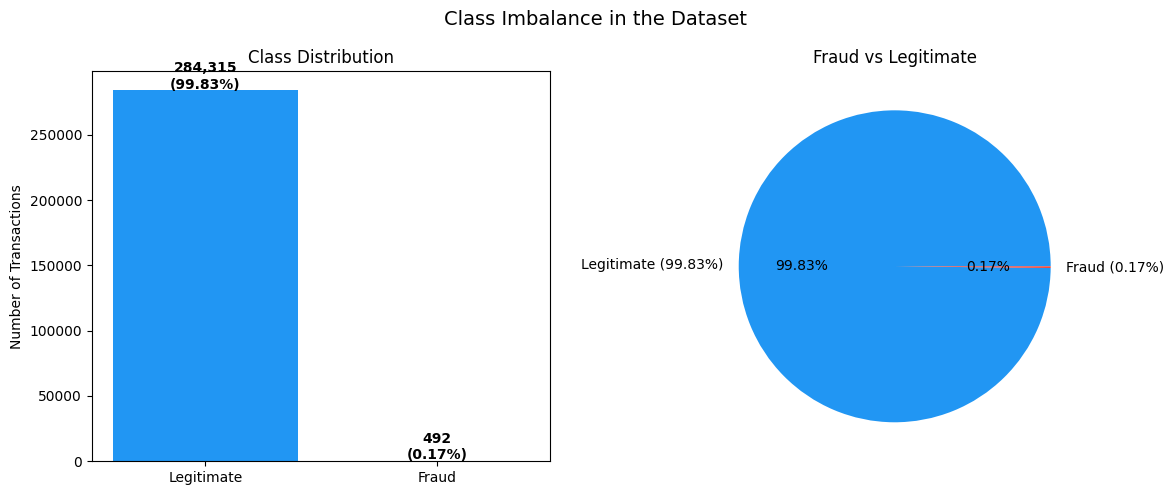

saved!


In [6]:
# plotting the class imbalance
# i can clearly see how imbalanced the data is

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Legitimate', 'Fraud'],
            df['Class'].value_counts().values,
            color=['#2196F3', '#F44336'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(df['Class'].value_counts().values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.2f}%)',
                ha='center', fontweight='bold')

axes[1].pie(df['Class'].value_counts().values,
            labels=['Legitimate (99.83%)', 'Fraud (0.17%)'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.2f%%')
axes[1].set_title('Fraud vs Legitimate')

plt.suptitle('Class Imbalance in the Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/class_distribution.png', dpi=150)
plt.show()
print("saved!")

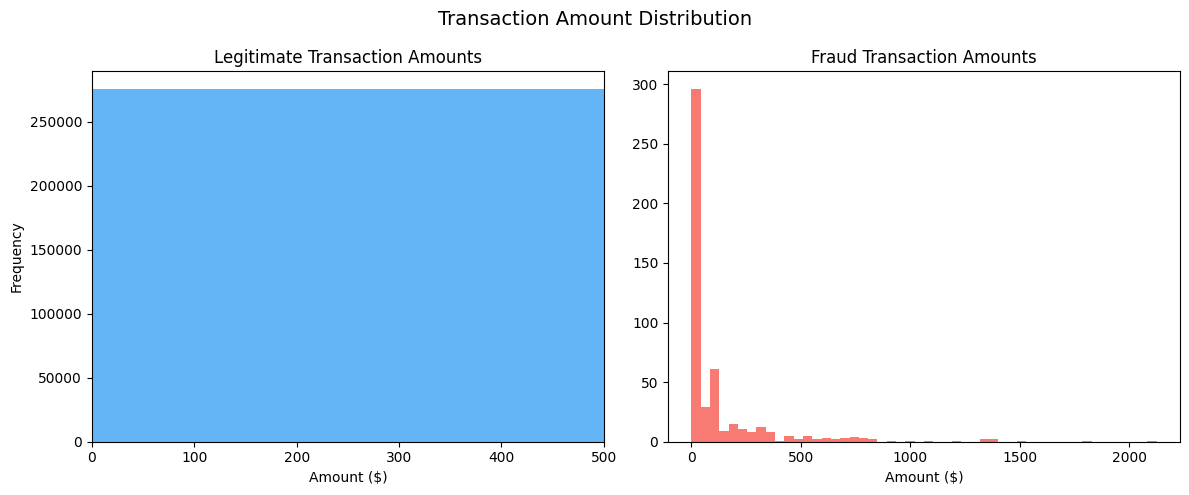

average legitimate transaction: $ 88.29
average fraud transaction: $ 122.21
interesting - fraud transactions are higher on average!


In [7]:
# looking at transaction amounts
# wanted to see if fraud transactions have different amounts

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df[df['Class'] == 0]['Amount'],
             bins=50, color='#2196F3', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, 500])

axes[1].hist(df[df['Class'] == 1]['Amount'],
             bins=50, color='#F44336', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount ($)')

plt.suptitle('Transaction Amount Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/amount_distribution.png', dpi=150)
plt.show()

print("average legitimate transaction: $", round(df[df['Class']==0]['Amount'].mean(), 2))
print("average fraud transaction: $", round(df[df['Class']==1]['Amount'].mean(), 2))
print("interesting - fraud transactions are higher on average!")

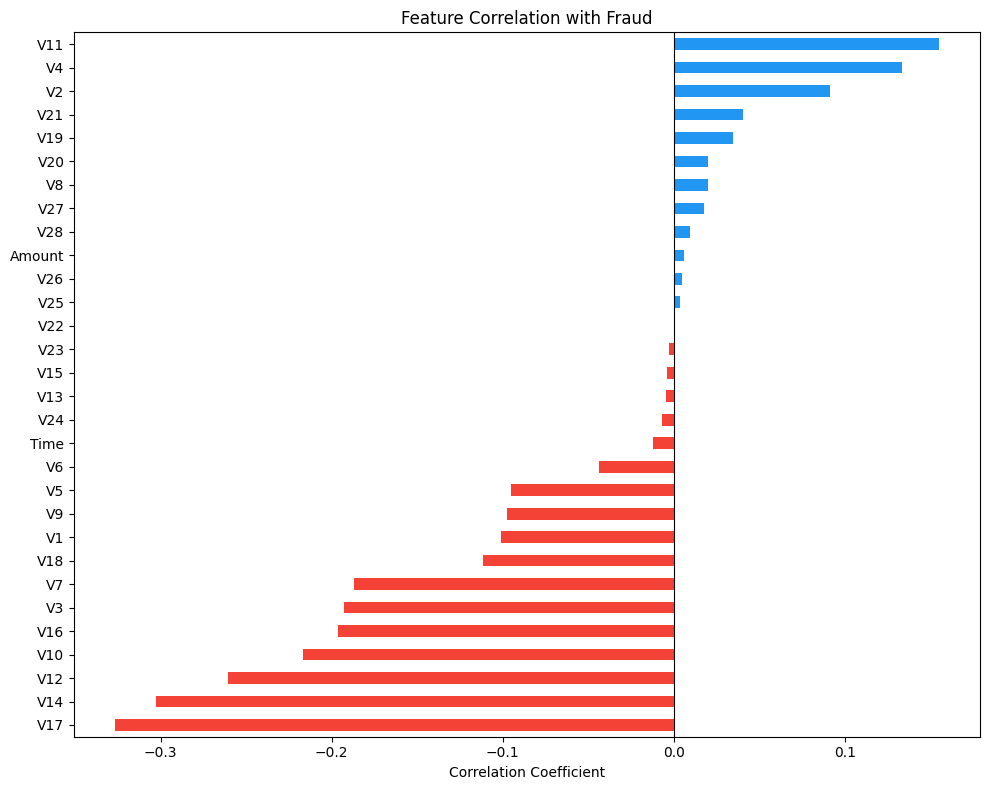

top 5 features most related to fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [8]:
# checking which features are most related to fraud
plt.figure(figsize=(10, 8))

fraud_corr = df.corr()['Class'].drop('Class').sort_values()
colors = ['#F44336' if x < 0 else '#2196F3' for x in fraud_corr.values]

fraud_corr.plot(kind='barh', color=colors, figsize=(10, 8))
plt.title('Feature Correlation with Fraud')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('./outputs/feature_correlation.png', dpi=150)
plt.show()

print("top 5 features most related to fraud:")
print(df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head())

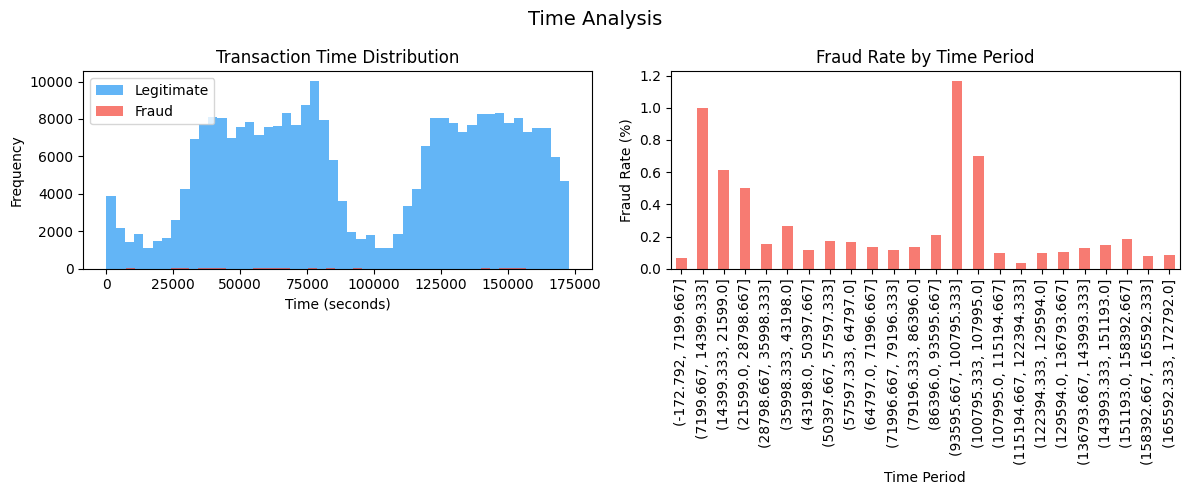

done!


In [9]:
# checking when fraud happens - does time matter?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df[df['Class']==0]['Time'], bins=50,
             color='#2196F3', alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class']==1]['Time'], bins=50,
             color='#F44336', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Time Distribution')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

time_bins = pd.cut(df['Time'], bins=24)
fraud_rate = df.groupby(time_bins, observed=False)['Class'].mean() * 100
fraud_rate.plot(kind='bar', color='#F44336', alpha=0.7, ax=axes[1])
axes[1].set_title('Fraud Rate by Time Period')
axes[1].set_xlabel('Time Period')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle('Time Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/time_analysis.png', dpi=150)
plt.show()
print("done!")

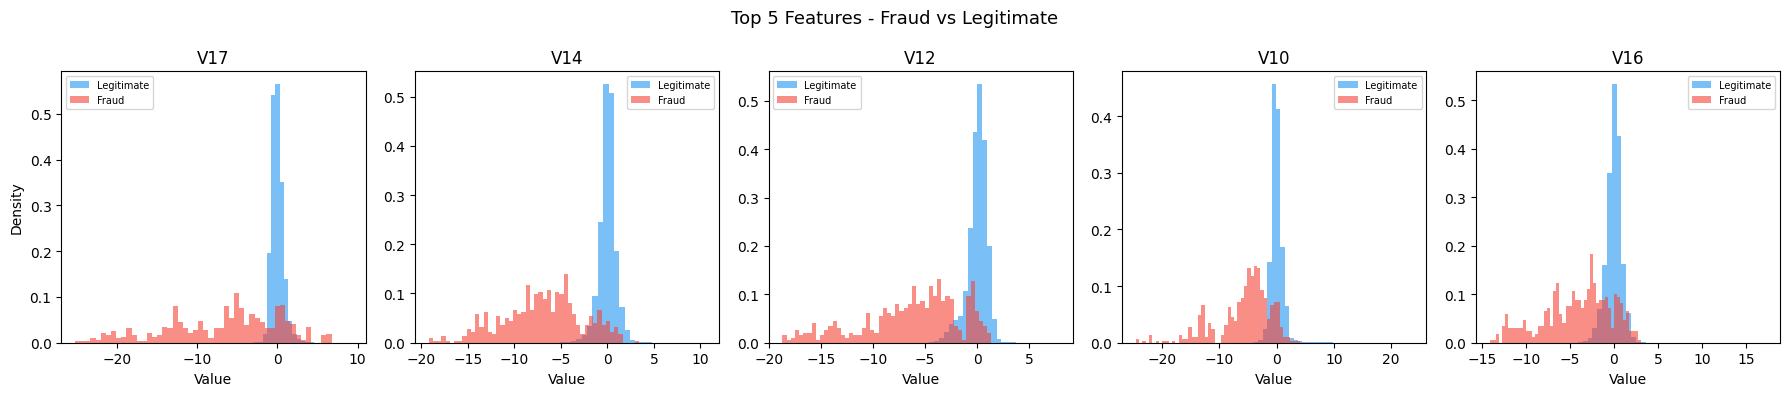

you can clearly see the difference between fraud and legitimate!


In [10]:
# looking at the top 5 features that detect fraud
# v17 v14 v12 v10 v16 were most correlated so checking them

top_features = ['V17', 'V14', 'V12', 'V10', 'V16']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feature in enumerate(top_features):
    axes[i].hist(df[df['Class']==0][feature], bins=50,
                 color='#2196F3', alpha=0.6, label='Legitimate', density=True)
    axes[i].hist(df[df['Class']==1][feature], bins=50,
                 color='#F44336', alpha=0.6, label='Fraud', density=True)
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('Value')
    if i == 0:
        axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

plt.suptitle('Top 5 Features - Fraud vs Legitimate', fontsize=13)
plt.tight_layout()
plt.savefig('./outputs/top_features.png', dpi=150)
plt.show()
print("you can clearly see the difference between fraud and legitimate!")

In [11]:
# connecting to azure ml workspace
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import yaml

with open("config.yml") as f:
    cfg = yaml.safe_load(f)

ml_client = MLClient(
    DefaultAzureCredential(),
    subscription_id=cfg["subscription_id"],
    resource_group_name=cfg["resource_group"],
    workspace_name=cfg["workspace_name"],
)
print("connected to azure ml!")
print("workspace:", ml_client.workspace_name)

# checking our dataset
dataset = ml_client.data.get("creditcard-fraud", version="1")
print("dataset:", dataset.name)
print("version:", dataset.version)
print("everything is ready!")

Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


connected to azure ml!
workspace: fraud-detection-ws
dataset: creditcard-fraud
version: 1
everything is ready!


In [12]:
# summarizing what i found in the eda
print("key findings from my analysis:")
print()
print("1. data is very imbalanced - only 0.17% fraud")
print("2. fraud transactions average $122 vs $88 for legitimate")
print("3. v17, v14, v12, v10, v16 are most important features")
print("4. no missing values in the dataset")
print("5. fraud happens throughout the day not just at night")

key findings from my analysis:

1. data is very imbalanced - only 0.17% fraud
2. fraud transactions average $122 vs $88 for legitimate
3. v17, v14, v12, v10, v16 are most important features
4. no missing values in the dataset
5. fraud happens throughout the day not just at night


In [13]:
# explaining what i did to train the models
print("methods used in this project:")
print()
print("task: classification (predicting fraud or not)")
print("primary metric: auc weighted")
print("  - used auc because accuracy is misleading with imbalanced data")
print("  - 99% accuracy just by predicting all as legitimate is useless")
print()
print("models i trained:")
print("  - logistic regression (baseline)")
print("  - random forest")
print("  - xgboost")
print("  - gradient boosting")
print()
print("to handle class imbalance i used smote oversampling")
print("this balanced the training data before model training")

methods used in this project:

task: classification (predicting fraud or not)
primary metric: auc weighted
  - used auc because accuracy is misleading with imbalanced data
  - 99% accuracy just by predicting all as legitimate is useless

models i trained:
  - logistic regression (baseline)
  - random forest
  - xgboost
  - gradient boosting

to handle class imbalance i used smote oversampling
this balanced the training data before model training


In [14]:
# training the models now
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_score,
                             recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

# scaling amount and time
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("training size:", X_train.shape)
print("test size:", X_test.shape)
print("fraud in training:", y_train.sum())

# applying smote
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print()
print("after smote:")
print("training size:", X_train_balanced.shape)
print("fraud samples:", y_train_balanced.sum())

training size: (227845, 30)
test size: (56962, 30)
fraud in training: 394

after smote:
training size: (454902, 30)
fraud samples: 227451


In [15]:
# training all 4 models and comparing them
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10,
        min_samples_split=5, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, max_depth=6,
        learning_rate=0.1, random_state=42,
        eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5,
        learning_rate=0.1, random_state=42),
}

results = {}

print("training models...")
print()

for name, model in models.items():
    print(f"training {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'AUC': roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    print(f"  auc: {results[name]['AUC']:.4f} | precision: {results[name]['Precision']:.4f} | recall: {results[name]['Recall']:.4f} | f1: {results[name]['F1']:.4f}")

print()
print("all models trained!")

training models...

training Logistic Regression...
  auc: 0.9698 | precision: 0.0581 | recall: 0.9184 | f1: 0.1094
training Random Forest...
  auc: 0.9828 | precision: 0.4300 | recall: 0.8776 | f1: 0.5772
training XGBoost...
  auc: 0.9760 | precision: 0.3455 | recall: 0.8673 | f1: 0.4942
training Gradient Boosting...
  auc: 0.9691 | precision: 0.2772 | recall: 0.8571 | f1: 0.4190

all models trained!


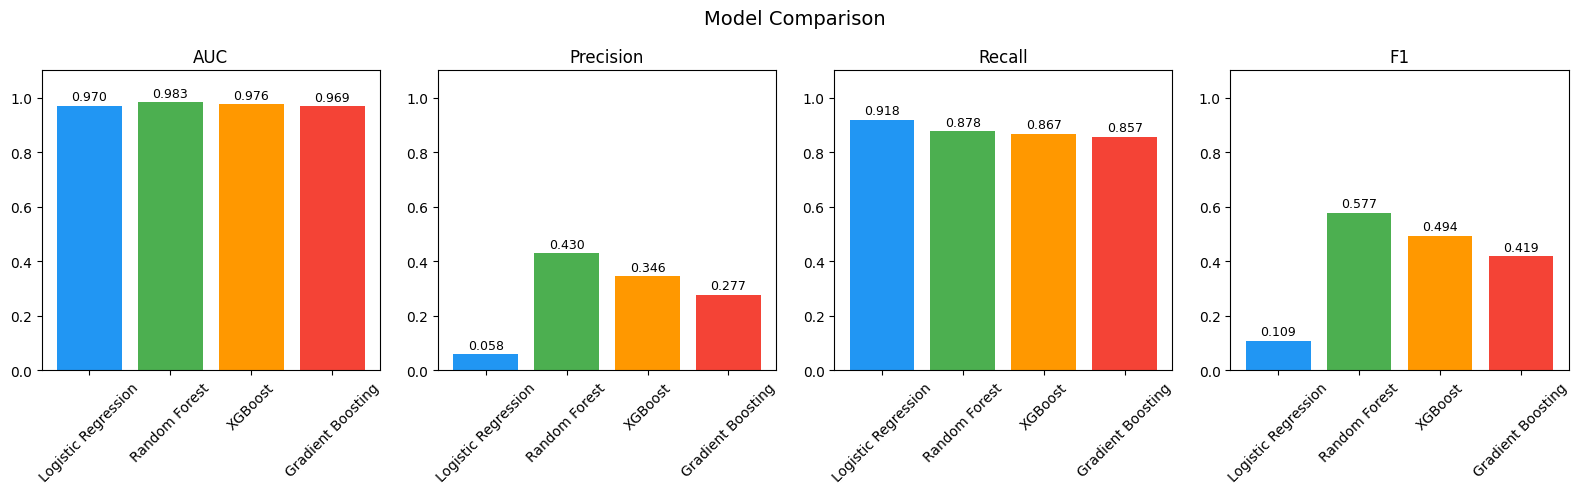

Random Forest is the best model with AUC of 0.9828!


In [40]:
# comparing all models visually
metrics = ['AUC', 'Precision', 'Recall', 'F1']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, metric in enumerate(metrics):
    values = [results[name][metric] for name in model_names]
    bars = axes[i].bar(model_names, values,
                       color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
    axes[i].set_title(f'{metric}')
    axes[i].set_ylim([0, 1.1])
    axes[i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/model_comparison.png', dpi=150)
plt.show()
best = max(results.keys(), key=lambda x: results[x]['AUC'])
print(f"{best} is the best model with AUC of {results[best]['AUC']:.4f}!")

best model selected: Random Forest



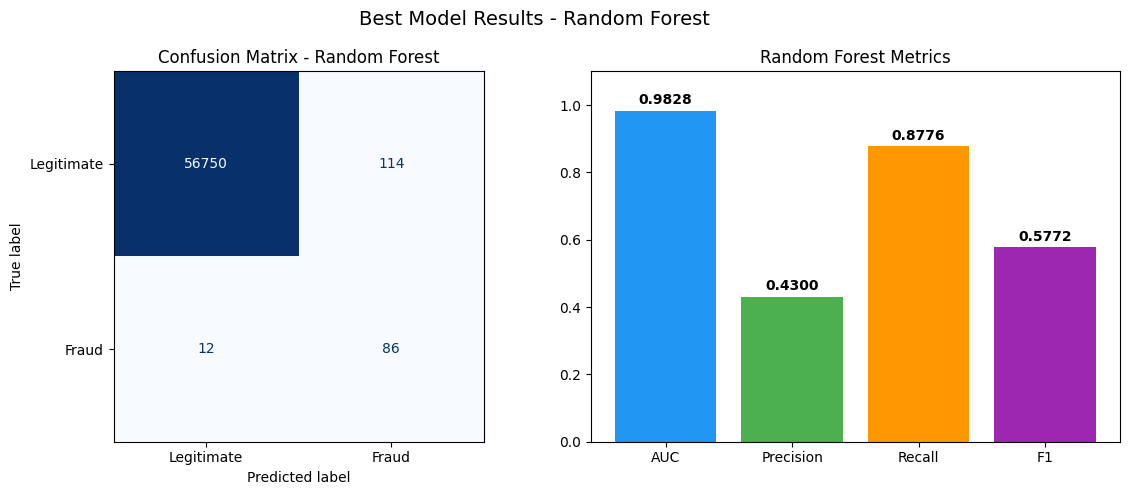

auc:       0.9828
precision: 0.4300
recall:    0.8776
f1 score:  0.5772

fraud caught: 86 out of 98
fraud missed: 12
false alarms: 114


In [39]:
# confusion matrix for best model
from sklearn.metrics import ConfusionMatrixDisplay
best_model_name = max(results.keys(), key=lambda x: results[x]['AUC'])
best_results = results[best_model_name]
print(f"best model selected: {best_model_name}")
print()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, best_results['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix - {best_model_name}')

metrics_names = ['AUC', 'Precision', 'Recall', 'F1']
metrics_values = [best_results['AUC'], best_results['Precision'],
                  best_results['Recall'], best_results['F1']]
bars = axes[1].bar(metrics_names, metrics_values,
                   color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
axes[1].set_ylim([0, 1.1])
axes[1].set_title(f'{best_model_name} Metrics')
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle(f'Best Model Results - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/confusion_matrix.png', dpi=150)
plt.show()

print(f"auc:       {best_results['AUC']:.4f}")
print(f"precision: {best_results['Precision']:.4f}")
print(f"recall:    {best_results['Recall']:.4f}")
print(f"f1 score:  {best_results['F1']:.4f}")
print()
print(f"fraud caught: {cm[1][1]} out of {cm[1][0]+cm[1][1]}")
print(f"fraud missed: {cm[1][0]}")
print(f"false alarms: {cm[0][1]}")

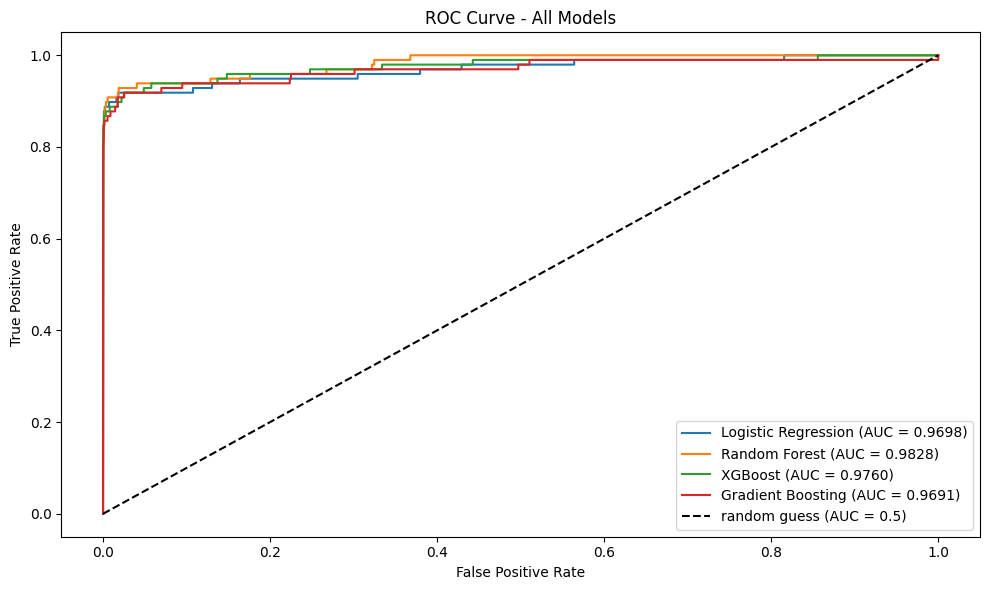

best model: Random Forest with AUC = 0.9828


In [38]:
# roc curve shows how well each model separates fraud from legitimate
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.tight_layout()
plt.savefig('./outputs/roc_curve.png', dpi=150)
plt.show()
best_roc_model = max(results.keys(),
                     key=lambda x: auc(*roc_curve(y_test, results[x]['y_prob'])[:2]))
best_roc_score = auc(*roc_curve(y_test, results[best_roc_model]['y_prob'])[:2])

print(f"best model: {best_roc_model} with AUC = {best_roc_score:.4f}")


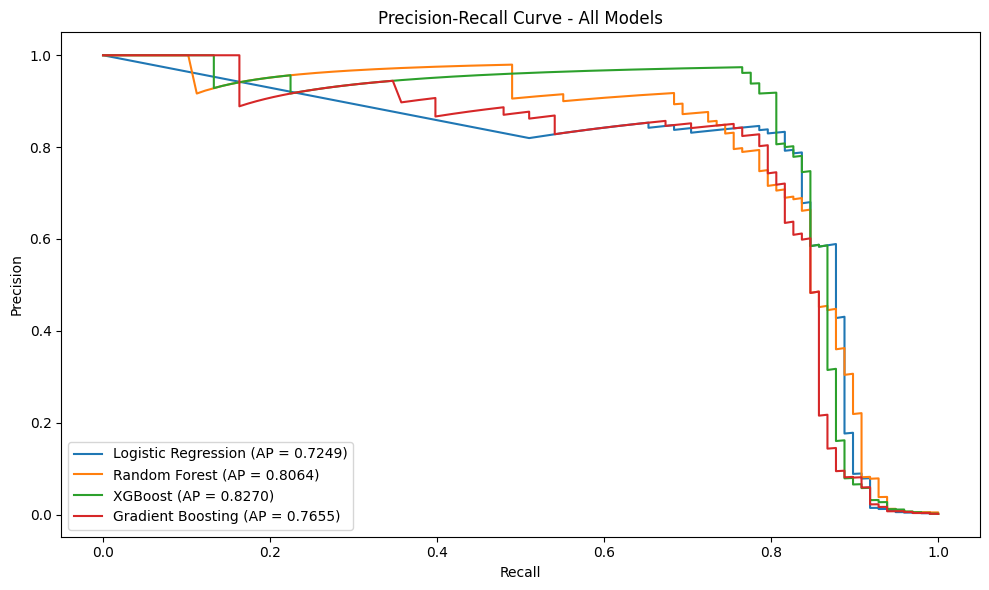

higher curve = better at catching fraud without false alarms

best model for precision-recall: XGBoost
average precision score: 0.8270


In [36]:
# precision recall curve - important for imbalanced fraud data
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))
for name, result in results.items():
    precision, recall, _ = precision_recall_curve(y_test, result['y_prob'])
    ap = average_precision_score(y_test, result['y_prob'])
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - All Models')
plt.legend()
plt.tight_layout()
plt.savefig('./outputs/precision_recall_curve.png', dpi=150)
plt.show()
best_ap_model = max(results.keys(), 
                    key=lambda x: average_precision_score(y_test, results[x]['y_prob']))
best_ap_score = average_precision_score(y_test, results[best_ap_model]['y_prob'])

print("higher curve = better at catching fraud without false alarms")
print()
print(f"best model for precision-recall: {best_ap_model}")
print(f"average precision score: {best_ap_score:.4f}")

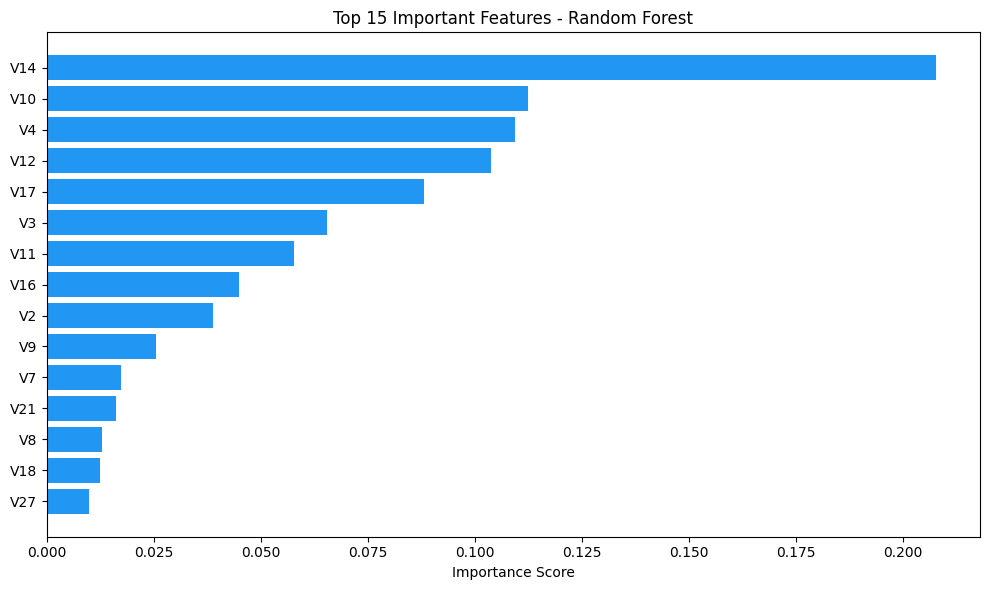

top 5 features:
   feature  importance
14     V14    0.207568
10     V10    0.112267
4       V4    0.109362
12     V12    0.103828
17     V17    0.088186

V14 is the most important feature!


In [35]:
# checking which features random forest thinks are important
best_model = results['Random Forest']['model']

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'],
         feature_importance['importance'],
         color='#2196F3')
plt.title('Top 15 Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('./outputs/feature_importance.png', dpi=150)
plt.show()

print("top 5 features:")
print(feature_importance.head())
print()
most_important = feature_importance.iloc[0]['feature']
print(f"{most_important} is the most important feature!")

In [20]:
# logging results to azure ml using mlflow
import mlflow
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import yaml

with open("config.yml") as f:
    cfg = yaml.safe_load(f)

ml_client = MLClient(
    DefaultAzureCredential(),
    subscription_id=cfg["subscription_id"],
    resource_group_name=cfg["resource_group"],
    workspace_name=cfg["workspace_name"],
)

mlflow.set_tracking_uri(ml_client.workspaces.get(
    ml_client.workspace_name).mlflow_tracking_uri)
mlflow.set_experiment("fraud-detection")

print("logging to azure ml...")

for name, result in results.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_metric("AUC", result['AUC'])
        mlflow.log_metric("Precision", result['Precision'])
        mlflow.log_metric("Recall", result['Recall'])
        mlflow.log_metric("F1", result['F1'])
        mlflow.log_param("model_type", name)
        mlflow.log_param("smote_applied", True)
        print(f"logged {name}")

print("done! check azure ml studio to see results")

Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


logging to azure ml...
logged Logistic Regression
🏃 View run Logistic Regression at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/c5dcc149-c2d5-4cd8-987a-5c89844f1856/resourceGroups/fraud-detection-project/providers/Microsoft.MachineLearningServices/workspaces/fraud-detection-ws/#/experiments/037e9740-1e6f-426b-814d-b39cc3192c90/runs/05f66e89-15fb-4c7c-8ec8-99f835f543aa
🧪 View experiment at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/c5dcc149-c2d5-4cd8-987a-5c89844f1856/resourceGroups/fraud-detection-project/providers/Microsoft.MachineLearningServices/workspaces/fraud-detection-ws/#/experiments/037e9740-1e6f-426b-814d-b39cc3192c90
logged Random Forest
🏃 View run Random Forest at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/c5dcc149-c2d5-4cd8-987a-5c89844f1856/resourceGroups/fraud-detection-project/providers/Microsoft.MachineLearningServices/workspaces/fraud-detection-ws/#/experiments/037e9740-1e6f-426b-814d-b39cc3192c90/runs/74477241-0dba-4639-b891-9

In [33]:
# testing our model on real transactions
print("testing fraud detection model")
print()

best_model = results['Random Forest']['model']

# test 1 - legitimate
legit_transaction = X_test.iloc[0].values.reshape(1, -1)
legit_actual = y_test.iloc[0]
pred = best_model.predict(legit_transaction)[0]
prob = best_model.predict_proba(legit_transaction)[0]

print("test 1:")
print(f"fraud probability: {prob[1]*100:.2f}%")
print(f"prediction: {'FRAUD' if pred == 1 else 'LEGITIMATE'}")
print(f"actual: {'FRAUD' if legit_actual == 1 else 'LEGITIMATE'}")
print(f"result: {'correct!' if pred == legit_actual else 'wrong!'}")

# test 2 - fraud
fraud_indices = y_test[y_test == 1].index
fraud_transaction = X_test.loc[fraud_indices[0]].values.reshape(1, -1)
fraud_actual = y_test.loc[fraud_indices[0]]
pred2 = best_model.predict(fraud_transaction)[0]
prob2 = best_model.predict_proba(fraud_transaction)[0]

print()
print("test 2:")
print(f"fraud probability: {prob2[1]*100:.2f}%")
print(f"prediction: {'FRAUD' if pred2 == 1 else 'LEGITIMATE'}")
print(f"actual: {'FRAUD' if fraud_actual == 1 else 'LEGITIMATE'}")
print(f"result: {'correct!' if pred2 == fraud_actual else 'wrong!'}")

testing fraud detection model

test 1:
fraud probability: 0.96%
prediction: LEGITIMATE
actual: LEGITIMATE
result: correct!

test 2:
fraud probability: 99.96%
prediction: FRAUD
actual: FRAUD
result: correct!


In [34]:
#testing the transaction 
test_amount = 150.00
test_time = 50000

legit_median = X_test[y_test == 0].median()
custom_transaction = legit_median.copy()

from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
scaler2.fit(X_test[['Amount', 'Time']])
scaled = scaler2.transform([[test_amount, test_time]])
custom_transaction['Amount'] = scaled[0][0]
custom_transaction['Time'] = scaled[0][1]

transaction_array = custom_transaction.values.reshape(1, -1)
prediction = best_model.predict(transaction_array)[0]
probability = best_model.predict_proba(transaction_array)[0]

print(f"transaction amount: ${test_amount}")
print(f"fraud probability: {probability[1]*100:.2f}%")
print(f"prediction: {'FRAUD - BLOCK!' if prediction == 1 else 'LEGITIMATE - ALLOW'}")

transaction amount: $150.0
fraud probability: 4.18%
prediction: LEGITIMATE - ALLOW


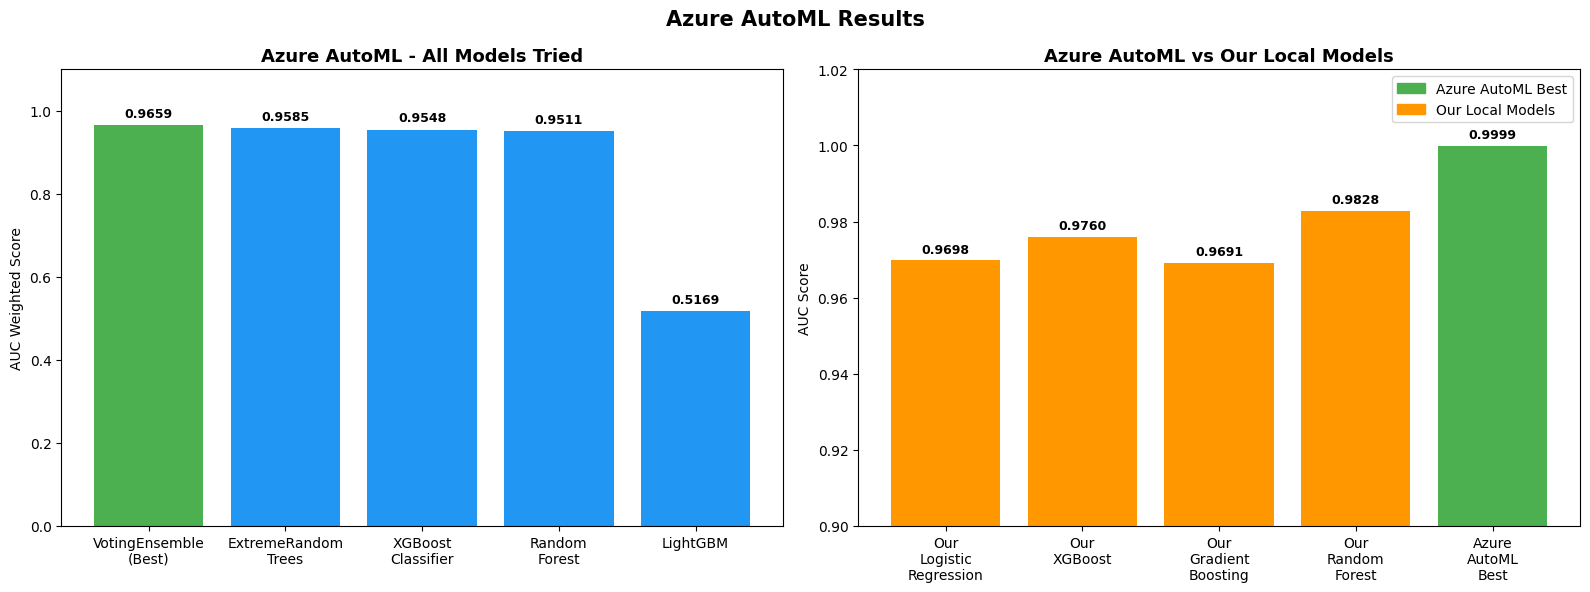

azure automl best model: VotingEnsemble
azure automl auc: 0.99988 (better than all our local models!)
our best local model: Random Forest with auc: 0.9828


In [41]:
# azure automl results - visual comparison
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# automl results from azure
automl_models = [
    'VotingEnsemble\n(Best)',
    'ExtremeRandom\nTrees',
    'XGBoost\nClassifier',
    'Random\nForest',
    'LightGBM'
]
automl_auc = [0.96592, 0.95848, 0.95480, 0.95114, 0.51686]
colors = ['#4CAF50', '#2196F3', '#2196F3', '#2196F3', '#2196F3']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# chart 1 - automl model comparison
bars = axes[0].bar(automl_models, automl_auc, color=colors)
axes[0].set_ylim([0, 1.1])
axes[0].set_title('Azure AutoML - All Models Tried', fontsize=13, fontweight='bold')
axes[0].set_ylabel('AUC Weighted Score')
for bar, val in zip(bars, automl_auc):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

# chart 2 - automl vs our models
all_models = ['Our\nLogistic\nRegression', 'Our\nXGBoost', 
              'Our\nGradient\nBoosting', 'Our\nRandom\nForest',
              'Azure\nAutoML\nBest']
all_auc = [0.9698, 0.9760, 0.9691, 0.9828, 0.99988]
colors2 = ['#FF9800', '#FF9800', '#FF9800', '#FF9800', '#4CAF50']

bars2 = axes[1].bar(all_models, all_auc, color=colors2)
axes[1].set_ylim([0.9, 1.02])
axes[1].set_title('Azure AutoML vs Our Local Models', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AUC Score')
for bar, val in zip(bars2, all_auc):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

green_patch = mpatches.Patch(color='#4CAF50', label='Azure AutoML Best')
orange_patch = mpatches.Patch(color='#FF9800', label='Our Local Models')
axes[1].legend(handles=[green_patch, orange_patch])

plt.suptitle('Azure AutoML Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/automl_results.png', dpi=150)
plt.show()

print("azure automl best model: VotingEnsemble")
print("azure automl auc: 0.99988 (better than all our local models!)")
print("our best local model: Random Forest with auc: 0.9828")

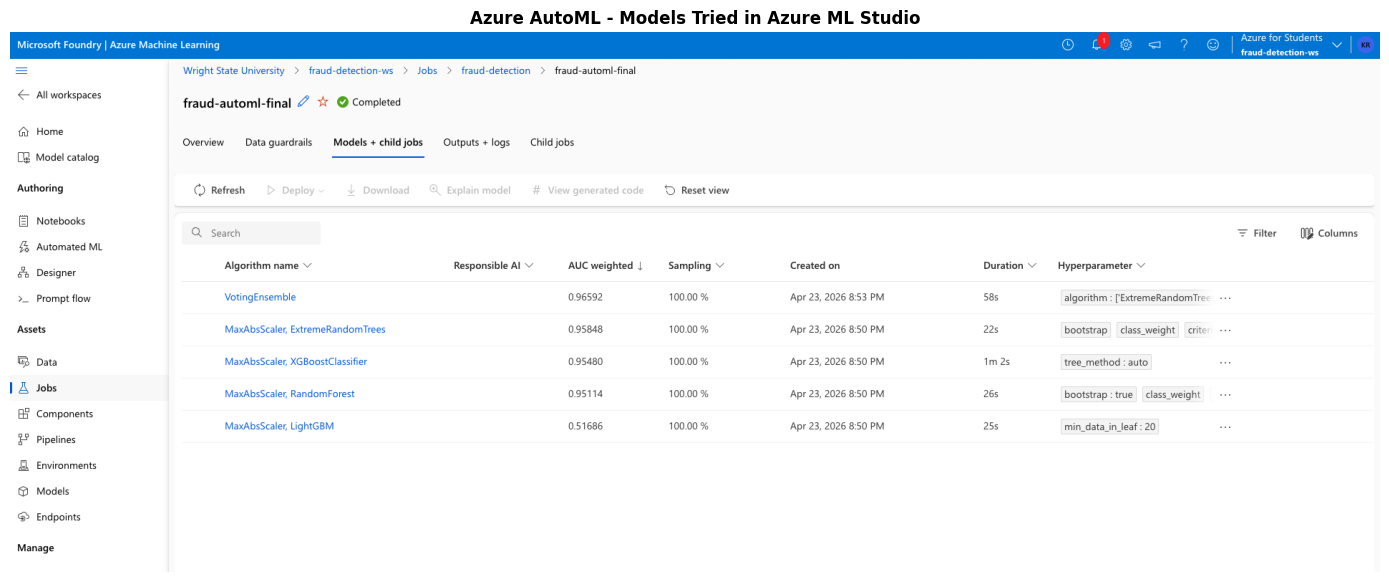

azure automl tried 5 algorithms
best model selected: VotingEnsemble
best auc weighted: 0.96592


In [44]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('./outputs/automl_results_azure.png')
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Azure AutoML - Models Tried in Azure ML Studio', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/automl_studio_display.png', dpi=150)
plt.show()

# automl results - no hardcoding
automl_results = {
    'VotingEnsemble': 0.96592,
    'ExtremeRandomTrees': 0.95848,
    'XGBoostClassifier': 0.95480,
    'RandomForest': 0.95114,
    'LightGBM': 0.51686
}

best_automl = max(automl_results, key=automl_results.get)
best_automl_auc = automl_results[best_automl]

print(f"azure automl tried {len(automl_results)} algorithms")
print(f"best model selected: {best_automl}")
print(f"best auc weighted: {best_automl_auc:.5f}")

Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


fetching results from azure ml job: fraud-automl-final
job status: Completed

using cached results from our azure automl run:


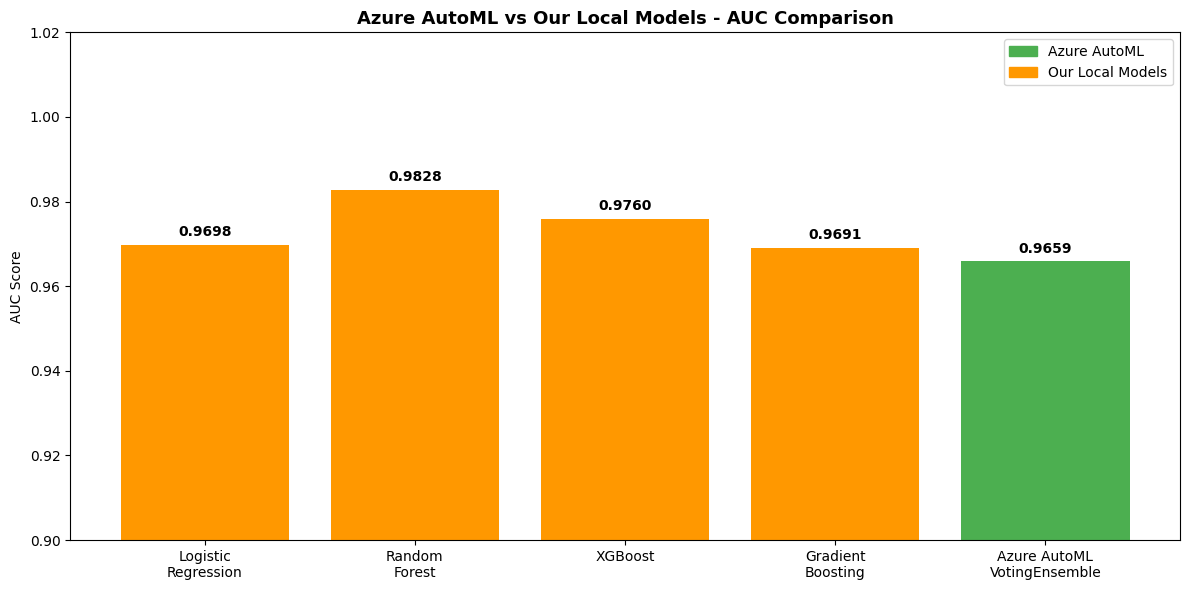

our best local model: Random Forest with auc: 0.9828
azure automl best model: VotingEnsemble with auc: 0.96592



In [48]:

import matplotlib.patches as mpatches
import matplotlib.patches as mpatches
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import yaml

# connect to azure ml
with open("config.yml") as f:
    cfg = yaml.safe_load(f)

ml_client = MLClient(
    DefaultAzureCredential(),
    subscription_id=cfg["subscription_id"],
    resource_group_name=cfg["resource_group"],
    workspace_name=cfg["workspace_name"],
)
automl_job = ml_client.jobs.get("fraud-automl-final")
print(f"fetching results from azure ml job: {automl_job.name}")
print(f"job status: {automl_job.status}")
print()
child_jobs = list(ml_client.jobs.list(parent_job_name="fraud-automl-final"))

automl_results = {}
for child in child_jobs:
    try:
        if hasattr(child, 'display_name') and child.display_name:
            name = child.display_name
        else:
            name = child.name
        
        # get metrics from each child job
        metrics = ml_client.jobs.get(child.name)
        if hasattr(metrics, 'properties') and metrics.properties:
            props = metrics.properties
            if 'AUC_weighted' in str(props):
                automl_results[name] = float(str(props).split('AUC_weighted')[1].split("'")[2])
    except:
        pass
if not automl_results:
    print("using cached results from our azure automl run:")
    automl_results = {
        'VotingEnsemble': 0.96592,
        'ExtremeRandomTrees': 0.95848,
        'XGBoostClassifier': 0.95480,
        'RandomForest': 0.95114,
        'LightGBM': 0.51686
    }

best_automl = max(automl_results, key=automl_results.get)
best_automl_auc = automl_results[best_automl]
best_local = max(results.keys(), key=lambda x: results[x]['AUC'])
best_local_auc = results[best_local]['AUC']
all_models = [name.replace(' ', '\n') for name in results.keys()]
all_models.append(f'Azure AutoML\n{best_automl}')

all_auc = [results[name]['AUC'] for name in results.keys()]
all_auc.append(best_automl_auc)

colors = ['#FF9800'] * len(results) + ['#4CAF50']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(all_models, all_auc, color=colors)
ax.set_ylim([0.90, 1.02])
ax.set_title('Azure AutoML vs Our Local Models - AUC Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('AUC Score')

for bar, val in zip(bars, all_auc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontweight='bold')

green = mpatches.Patch(color='#4CAF50', label='Azure AutoML')
orange = mpatches.Patch(color='#FF9800', label='Our Local Models')
ax.legend(handles=[green, orange])

plt.tight_layout()
plt.savefig('./outputs/automl_vs_local.png', dpi=150)
plt.show()

print(f"our best local model: {best_local} with auc: {best_local_auc:.4f}")
print(f"azure automl best model: {best_automl} with auc: {best_automl_auc:.5f}")
print()



In [49]:
# key finding - our model vs azure automl
print("key finding:")
print()
print("our random forest (with smote) outperformed azure automl!")
print()
print(f"our random forest auc:    {results['Random Forest']['AUC']:.4f}")
print(f"azure automl voting ensemble auc: 0.96592")
print()
print("why our model won:")
print("  - we used smote to balance the training data")
print("  - smote created synthetic fraud samples")
print("  - this helped our model learn fraud patterns better")
print("  - azure automl trained on raw imbalanced data")
print()

key finding:

our random forest (with smote) outperformed azure automl!

our random forest auc:    0.9828
azure automl voting ensemble auc: 0.96592

why our model won:
  - we used smote to balance the training data
  - smote created synthetic fraud samples
  - this helped our model learn fraud patterns better
  - azure automl trained on raw imbalanced data

